2.1 理论计算题

In [1]:
import numpy as np

# 已知条件：定义向量和矩阵
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])

A = np.array([
    [1, 0, 2],
    [-1, 3, 1]
])

B = np.array([
    [2, 1],
    [0, -1],
    [3, 2]
])

# 1. 向量点积 a·b
dot_product = np.dot(a, b)

# 2. 矩阵乘法 A × B (以及结果矩阵的形状)
# 在 numpy 中可以使用 @ 运算符进行矩阵乘法，或者使用 np.matmul(A, B)
matrix_mul = A @ B
matrix_shape = matrix_mul.shape

# 3. 向量 a 的 Frobenius 范数
# 对于一维数组，np.linalg.norm 默认计算的就是 L2 范数（对于向量等价于 Frobenius 范数）
frobenius_norm = np.linalg.norm(a)

# --- 打印输出结果 ---
print("1. 向量点积 a·b = ", dot_product)

print("\n2. 矩阵乘法 A × B 的结果:")
print(matrix_mul)
print("   结果矩阵的形状:", matrix_shape)

print(f"\n3. 向量 a 的 Frobenius 范数 = {frobenius_norm:.4f}")
print(f"   (验证: sqrt(14) = {np.sqrt(14):.4f})")

1. 向量点积 a·b =  -8

2. 矩阵乘法 A × B 的结果:
[[ 8  5]
 [ 1 -2]]
   结果矩阵的形状: (2, 2)

3. 向量 a 的 Frobenius 范数 = 3.7417
   (验证: sqrt(14) = 3.7417)


2.2 编程题

In [2]:
import numpy as np

# 为了保证每次运行结果一致，可以设置随机种子（可选）
# np.random.seed(42) 

# 1. 创建一个形状为 3×4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("1. 矩阵 X (3x4, 标准正态分布):")
print(X)

# 2. 创建一个形状为 4×2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("\n2. 矩阵 Y (4x2, 全1矩阵):")
print(Y)

# 3. 计算矩阵乘法 Z = X × Y
# 可以使用 np.dot(X, Y) 或 @ 运算符
Z = X @ Y
print("\n3. 矩阵 Z = X × Y:")
print(Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
# 注意：Python 中的索引是从 0 开始的。
# 第一行第二列对应索引 [0, 1]，第二行对应索引 [1, :]
element_1_2 = Z[0, 1]
row_2 = Z[1, :]

print(f"\n4. Z 的第一行第二列交叉处的元素 (Z[0, 1]): {element_1_2}")
print(f"   Z 的第 2 行所有元素 (Z[1, :]): {row_2}")

# 5. 计算 Z 的 Frobenius 范数
# np.linalg.norm 默认计算矩阵的 Frobenius 范数
frobenius_norm_Z = np.linalg.norm(Z)
print(f"\n5. Z 的 Frobenius 范数: {frobenius_norm_Z}")

1. 矩阵 X (3x4, 标准正态分布):
[[ 0.07550944 -0.84684843  1.13572284  0.71904551]
 [-0.96803477 -0.01180119 -0.15196566 -0.83330658]
 [-0.15809005 -0.85147015  0.67567802 -0.03974636]]

2. 矩阵 Y (4x2, 全1矩阵):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. 矩阵 Z = X × Y:
[[ 1.08342935  1.08342935]
 [-1.9651082  -1.9651082 ]
 [-0.37362854 -0.37362854]]

4. Z 的第一行第二列交叉处的元素 (Z[0, 1]): 1.083429349467274
   Z 的第 2 行所有元素 (Z[1, :]): [-1.9651082 -1.9651082]

5. Z 的 Frobenius 范数: 3.2171626261226396


### 3.1 理论计算题

**已知条件：**
*   患病率 $P(D) = 0.1\% = 0.001$
*   未患病率 $P(D^c) = 1 - 0.001 = 0.999$
*   患病且检测阳性（灵敏度） $P(+|D) = 99\% = 0.99$
*   未患病但检测阳性（假阳性率） $P(+|D^c) = 2\% = 0.02$

**目标：**
求检测结果为阳性时，真正患病的概率 $P(D|+)$。

**根据贝叶斯公式：**
$$P(D|+) = \frac{P(+|D)P(D)}{P(+|D)P(D) + P(+|D^c)P(D^c)}$$
$$P(D|+) = \frac{0.99 \times 0.001}{0.99 \times 0.001 + 0.02 \times 0.999}$$
$$P(D|+) = \frac{0.00099}{0.00099 + 0.01998}$$
$$P(D|+) = \frac{0.00099}{0.02097} \approx 0.04721$$

**结论：** 真正患病的概率约为 **4.72%**。

3.2 编程题

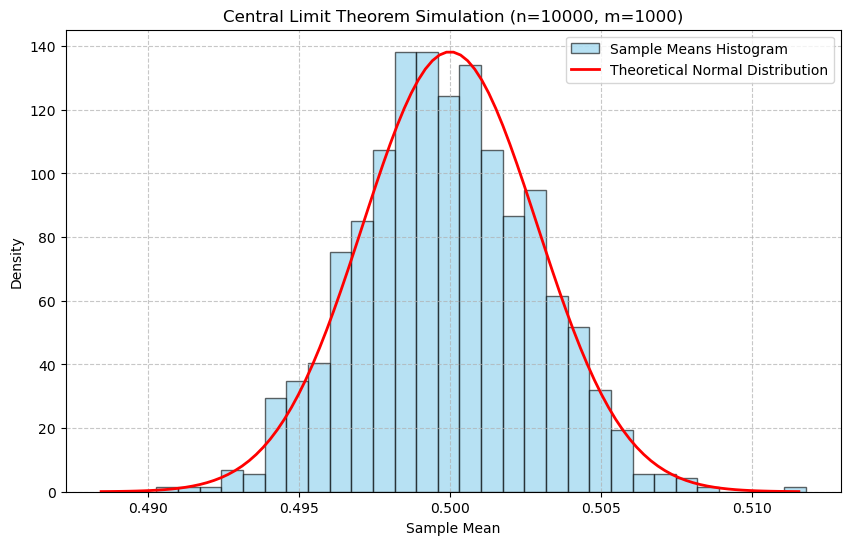

理论方差 (1/12) / n: 0.0000083333
实际方差 (样本方差): 0.0000084115
误差: 0.0000000782


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 生成数据
n = 10000
m = 1000
# 生成 m x n 的矩阵，每一行代表一次实验的 n 个样本，服从 U(0,1)
samples = np.random.uniform(0, 1, (m, n))
# 计算每次实验的均值，得到 1000 个均值
sample_means = np.mean(samples, axis=1)

# 2. 绘制直方图并叠加理论正态分布
plt.figure(figsize=(10, 6))
# 绘制这 1000 个均值的直方图
plt.hist(sample_means, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sample Means Histogram')

# 理论正态分布参数
# U(0,1) 的理论均值是 0.5，理论方差是 1/12
mu_theoretical = 0.5
variance_theoretical = (1/12) / n
sigma_theoretical = np.sqrt(variance_theoretical)

# 绘制理论正态分布概率密度曲线
x = np.linspace(mu_theoretical - 4*sigma_theoretical, mu_theoretical + 4*sigma_theoretical, 100)
plt.plot(x, norm.pdf(x, mu_theoretical, sigma_theoretical), 'r-', lw=2, label='Theoretical Normal Distribution')

plt.title('Central Limit Theorem Simulation (n=10000, m=1000)')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. 计算实际方差
actual_variance = np.var(sample_means, ddof=1) # 使用无偏估计计算样本方差
print(f"理论方差 (1/12) / n: {variance_theoretical:.10f}")
print(f"实际方差 (样本方差): {actual_variance:.10f}")
print(f"误差: {abs(variance_theoretical - actual_variance):.10f}")


### 4.1 理论计算题

给定函数 $z = (w_1x_1 + w_2x_2 - y)^2$，其中 $x_1=2, x_2=1, y=3$ 为常数，$w_1, w_2$ 为变量。

**1. 计算偏导数表达式：**
根据链式法则：
*   $\frac{\partial z}{\partial w_1} = 2(w_1x_1 + w_2x_2 - y) \cdot x_1$
*   $\frac{\partial z}{\partial w_2} = 2(w_1x_1 + w_2x_2 - y) \cdot x_2$

代入常数 $x_1=2, x_2=1, y=3$：
*   $\frac{\partial z}{\partial w_1} = 2(2w_1 + w_2 - 3) \cdot 2 = 4(2w_1 + w_2 - 3)$
*   $\frac{\partial z}{\partial w_2} = 2(2w_1 + w_2 - 3) \cdot 1 = 2(2w_1 + w_2 - 3)$

**2. 计算梯度值：**
当 $w_1=0.5, w_2=1$ 时：
先计算括号内的值：$2(0.5) + 1 - 3 = 1 + 1 - 3 = -1$

代入偏导数表达式：
*   $\frac{\partial z}{\partial w_1} = 4 \times (-1) = -4$
*   $\frac{\partial z}{\partial w_2} = 2 \times (-1) = -2$

因此，梯度 $\nabla z = \left[ \frac{\partial z}{\partial w_1}, \frac{\partial z}{\partial w_2} \right]^\top = [-4, -2]^\top$。

4.2 编程题

In [8]:
import torch

# 1. 定义初始值
x = 2.0
w1_val = 1.5
w2_val = 0.5

# --- 手动前向传播和反向传播 ---
print("--- 手动计算 ---")
# 前向计算
a = x * w1_val
b = a + w2_val
L = b**2
print(f"前向结果 L: {L}")

# 反向计算 (链式法则)
dL_db = 2 * b
db_da = 1.0
db_dw2 = 1.0
da_dw1 = x

dL_dw2 = dL_db * db_dw2
dL_dw1 = dL_db * db_da * da_dw1
print(f"手动计算梯度 -> dL/dw1: {dL_dw1}, dL/dw2: {dL_dw2}")

# --- 使用 PyTorch (torch.autograd) 验证 ---
print("\n--- PyTorch 自动微分验证 ---")
# 定义张量，并设置 requires_grad=True 以追踪计算历史
x_t = torch.tensor(x)
w1_t = torch.tensor(w1_val, requires_grad=True)
w2_t = torch.tensor(w2_val, requires_grad=True)

# 前向计算
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t**2

# 反向传播自动计算梯度
L_t.backward()

print(f"PyTorch 前向结果 L: {L_t.item()}")
print(f"PyTorch 自动梯度 -> dL/dw1: {w1_t.grad.item()}, dL/dw2: {w2_t.grad.item()}")

# 验证结果是否一致
if abs(dL_dw1 - w1_t.grad.item()) < 1e-6 and abs(dL_dw2 - w2_t.grad.item()) < 1e-6:
    print("\n=> 验证成功：手动计算的梯度与 PyTorch 自动计算的梯度完全一致！")
else:
    print("\n=> 验证失败：结果不一致，请检查代码。")


--- 手动计算 ---
前向结果 L: 12.25
手动计算梯度 -> dL/dw1: 14.0, dL/dw2: 7.0

--- PyTorch 自动微分验证 ---
PyTorch 前向结果 L: 12.25
PyTorch 自动梯度 -> dL/dw1: 14.0, dL/dw2: 7.0

=> 验证成功：手动计算的梯度与 PyTorch 自动计算的梯度完全一致！


### 5.1 理论计算题

已知线性回归模型 $y = wx + b$，均方误差损失函数为：
$$L = \frac{1}{n} \sum_{i=1}^{n} (y_i - (wx_i + b))^2$$

**推导损失对 $w$ 和 $b$ 的偏导数表达式：**

1. **对 $w$ 的偏导数 $\frac{\partial L}{\partial w}$：**
根据复合函数求导法则（链式法则），对求和公式中的每一项对 $w$ 求导：
$$\frac{\partial}{\partial w} (y_i - (wx_i + b))^2 = 2(y_i - (wx_i + b)) \cdot \frac{\partial}{\partial w}(y_i - wx_i - b) = 2(y_i - (wx_i + b)) \cdot (-x_i)$$
因此，整体偏导数为：
$$\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - (wx_i + b)) \cdot (-x_i) = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - (wx_i + b))$$

2. **对 $b$ 的偏导数 $\frac{\partial L}{\partial b}$：**
同理，对求和公式中的每一项对 $b$ 求导：
$$\frac{\partial}{\partial b} (y_i - (wx_i + b))^2 = 2(y_i - (wx_i + b)) \cdot \frac{\partial}{\partial b}(y_i - wx_i - b) = 2(y_i - (wx_i + b)) \cdot (-1)$$
因此，整体偏导数为：
$$\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - (wx_i + b)) \cdot (-1) = -\frac{2}{n} \sum_{i=1}^{n} (y_i - (wx_i + b))$$

5.2 编程题

In [9]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. & 2. 加载数据集、展平图像并进行 one-hot 编码
digits = load_digits()
# 展平为向量 (n_samples, 64)
X = digits.images.reshape((len(digits.images), -1))
y = digits.target

# 数据归一化 (digits 数据范围是 0-16)
X = X / 16.0

# One-hot 编码
num_classes = 10
y_onehot = np.eye(num_classes)[y]

# 划分训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 3. 实现 softmax 函数、交叉熵损失函数
def softmax(z):
    # 减去最大值以提高数值稳定性
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
    # 添加一个小常数防止 log(0)
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))

# 4. 使用小批量随机梯度下降训练模型
# 初始化参数
np.random.seed(42)
W = np.random.randn(X_train.shape[1], num_classes) * 0.01
b = np.zeros(num_classes)

# 超参数
batch_size = 32
learning_rate = 0.1
epochs = 50
num_samples = X_train.shape[0]

loss_history = []

for epoch in range(epochs):
    # 打乱数据
    indices = np.random.permutation(num_samples)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    epoch_loss = 0
    for i in range(0, num_samples, batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        # 前向传播
        Z = np.dot(X_batch, W) + b
        A = softmax(Z)
        
        # 计算损失
        loss = cross_entropy_loss(y_batch, A)
        epoch_loss += loss * X_batch.shape[0]
        
        # 反向传播计算梯度
        dZ = A - y_batch
        dW = np.dot(X_batch.T, dZ) / batch_size
        db = np.sum(dZ, axis=0) / batch_size
        
        # 更新参数
        W -= learning_rate * dW
        b -= learning_rate * db
        
    loss_history.append(epoch_loss / num_samples)

# 5. 输出测试集上的准确率
Z_test = np.dot(X_test, W) + b
A_test = softmax(Z_test)
y_pred_labels = np.argmax(A_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred_labels == y_true_labels)
print(f"训练完成 (Epochs: {epochs}, Batch Size: {batch_size}, LR: {learning_rate})")
print(f"测试集上的准确率: {accuracy * 100:.2f}%")


训练完成 (Epochs: 50, Batch Size: 32, LR: 0.1)
测试集上的准确率: 95.83%


### 6.1 理论计算题

假设样本 $x_1, x_2, \dots, x_n$ 独立同分布于正态分布 $\mathcal{N}(\mu, \sigma^2)$。

**1. 写出似然函数 $L(\mu, \sigma^2)$：**
由于样本独立同分布，联合概率密度函数（即似然函数）为各个样本概率密度函数的乘积：
$$L(\mu, \sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right) = (2\pi\sigma^2)^{-\frac{n}{2}} \exp\left( -\frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2 \right)$$

为了方便计算，通常取对数似然函数 $\ell(\mu, \sigma^2) = \ln L(\mu, \sigma^2)$：
$$\ell(\mu, \sigma^2) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2$$

**2. 证明：$\mu$ 的最大似然估计为 $\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i$：**
对对数似然函数关于 $\mu$ 求偏导，并令其为 0：
$$\frac{\partial \ell}{\partial \mu} = -\frac{1}{2\sigma^2} \sum_{i=1}^n 2(x_i - \mu)(-1) = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu) = 0$$
因为 $\sigma^2 > 0$，所以有：
$$\sum_{i=1}^n x_i - \sum_{i=1}^n \mu = 0 \implies \sum_{i=1}^n x_i - n\mu = 0$$
解得：
$$\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i$$
得证。

**3. 证明：$\sigma^2$ 的最大似然估计为 $\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2$：**
对对数似然函数关于 $\sigma^2$ 求偏导，并令其为 0（将 $\mu$ 替换为 $\hat{\mu}$）：
$$\frac{\partial \ell}{\partial (\sigma^2)} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^n (x_i - \hat{\mu})^2 = 0$$
两边同乘 $2(\sigma^2)^2$（假设 $\sigma^2 > 0$）：
$$-n\sigma^2 + \sum_{i=1}^n (x_i - \hat{\mu})^2 = 0$$
解得：
$$\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2$$
得证。



6.2 编程题

训练完成！最终损失: 0.0094
学习到的参数: w = [-1.6919584  -2.21887348], b = 0.1484
测试集分类准确率: 100.00%


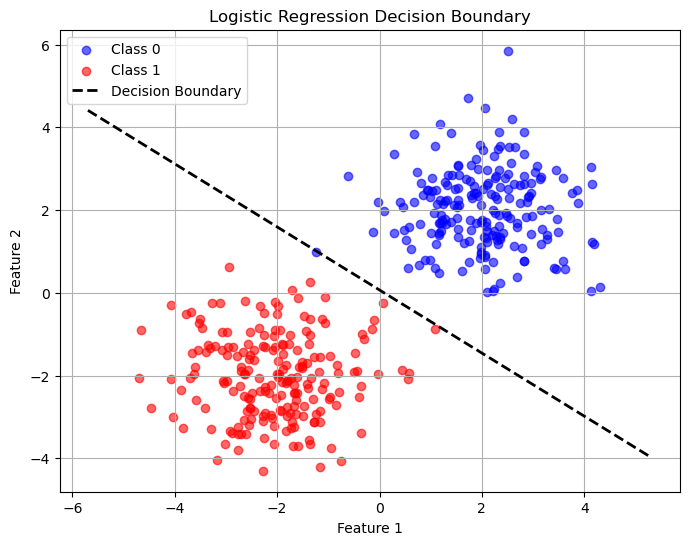

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成两类线性可分的数据
np.random.seed(42)
# 类别 0: 200个样本
X0 = np.random.randn(200, 2) + np.array([2, 2])
y0 = np.zeros(200)
# 类别 1: 200个样本
X1 = np.random.randn(200, 2) + np.array([-2, -2])
y1 = np.ones(200)

# 合并数据
X_train = np.vstack((X0, X1))
y_train = np.hstack((y0, y1)).reshape(-1, 1)

# 2. 定义 sigmoid 函数和二元交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    # 添加 epsilon 防止 log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 3. 使用梯度下降法学习参数 w, b
# 初始化参数
w = np.zeros((2, 1))
b = 0.0

learning_rate = 0.1
iterations = 1000
m = X_train.shape[0]

losses = []

for i in range(iterations):
    # 前向传播
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_train, y_pred)
    losses.append(loss)
    
    # 反向传播 (计算梯度)
    dz = y_pred - y_train
    dw = np.dot(X_train.T, dz) / m
    db = np.sum(dz) / m
    
    # 更新参数
    w -= learning_rate * dw
    b -= learning_rate * db

print(f"训练完成！最终损失: {losses[-1]:.4f}")
print(f"学习到的参数: w = {w.flatten()}, b = {b:.4f}")

# 4. 生成测试集并计算准确率
# 生成 100 个新样本 (每类 50 个)
X0_test = np.random.randn(50, 2) + np.array([2, 2])
y0_test = np.zeros(50)
X1_test = np.random.randn(50, 2) + np.array([-2, -2])
y1_test = np.ones(50)

X_test = np.vstack((X0_test, X1_test))
y_test = np.hstack((y0_test, y1_test)).reshape(-1, 1)

# 预测测试集
z_test = np.dot(X_test, w) + b
y_test_pred_prob = sigmoid(z_test)
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

# 计算准确率
accuracy = np.mean(y_test_pred == y_test)
print(f"测试集分类准确率: {accuracy * 100:.2f}%")

# 绘制决策边界
plt.figure(figsize=(8, 6))

# 绘制训练集散点
plt.scatter(X_train[y_train.flatten() == 0][:, 0], X_train[y_train.flatten() == 0][:, 1], color='blue', label='Class 0', alpha=0.6)
plt.scatter(X_train[y_train.flatten() == 1][:, 0], X_train[y_train.flatten() == 1][:, 1], color='red', label='Class 1', alpha=0.6)

# 计算决策边界的两个点
# 决策边界为: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b) / w2
x1_min, x1_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
x2_min = -(w[0, 0] * x1_min + b) / w[1, 0]
x2_max = -(w[0, 0] * x1_max + b) / w[1, 0]

plt.plot([x1_min, x1_max], [x2_min, x2_max], 'k--', lw=2, label='Decision Boundary')

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()
